# Boosting with LightGBM

In this practical we will use the `lightgbm` package to perform classification.

We'll use a dataset of online behaviour, with the aim of classifying visitors as likely to make, or not make, a purchase.

# Classification: the data

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset).

Each row summarises a visitor's history on an e-commerce site (12,330 visits in total).

The features are related to the type of page visited (and duration), various analytics metrics (bounce/exit rates), OS/browser used, region, and so on.

The binary variable we want to predict is "Revenue" - did the user eventually make a purchase?

In [8]:
import pandas as pd

data = pd.read_csv('data/online_shoppers_intention.csv')

data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

# Preparing the data - I

`lightgbm` requires data to be `int`, `float`, or `bool`. Categorical items will also need to be identified as such.

From looking at the dataset above, we have two categorical columns which are `str` type. Some other columns are `int` but represent categorical data too, e.g. `Region`.

Use the `.astype('category')` method available for `pandas` Series (each column in a DataFrame is a Series) to change these columns to the correct datatype.

In [10]:
# Your code here...

data[['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']] = data[['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']].astype('category')

data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  Traffi

# Preparing the data - II

As is standard, we will split up the data using `sklearn.model_selection.train_test_split` to create a training set and a test set. We will keep the test set aside to evaluate the models on unseen data, as a measure of how generalisable they are.

First, separate the predictive columns (the `X`) from the outcome variable (the `y`).

Then create your train and test sets using the default ratio of `train_test_split` and set the random state to be `136`. As we have imbalanced data set `stratify=y`, this will ensure that we have the same `y` ratio in both the train and test sets.

Call the variables `X_train`, `X_test`, `y_train`, and `y_test`.

In [11]:
from sklearn.model_selection import train_test_split

# Your code here...

X = data.drop('Revenue', axis=1)
y = data.Revenue

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=136)


Run the following cells to confirm that the target ratio is the same in both the train and test sets.

In [12]:
# y_train.value_counts(normalize=True)

In [13]:
# y_test.value_counts(normalize=True)

# Preparing the data - III

Normally we need to pre-process data for `sklearn` models. `lightgbm` comes with a `Dataset` class that will handle the data for us. It will use the column names of the `pandas` DataFrame to name the features.

For more advanced use, it can also apply individual weights to specific items in the data.

Set up two instances of `lgb.Dataset()` named `lgb_train` and `lgb_test`.

You can do this by passing the appropriate `X_` and `y_` arrays you created above.

For `lgb_test`, set the argument `reference=lgb_train`. This is so that when the model is pre-processing data (i.e. discretizing continuous features into histogram bins, and trying to combine categorical features,) it has access to the full range of possible data values, not just the ones that appear in the testing data.

For more information on what `lgb.Dataset()` is doing see the [documentation](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.Dataset.html).

In [14]:
import lightgbm as lgb

# Your code here...

lgb_train = lgb.Dataset(X_train, y_train)

lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)



# Setting parameters

`lightgbm` is highly configurable - see [the documentation](https://lightgbm.readthedocs.io/en/latest/Parameters.html) for a full list.

Some parameters are related to:

- performance: Using the GPU or multiple machines to speed up training
- task: regression, classification (binary or multi), ranking
- boosting algorithm: gradient boosting decision trees? Random forests? Something else?
- ensemble model parameters: learning rate, number of models in ensemble
- model-specific parameters: depth of decision trees, number of nodes per level

For now we will focus on parameters which are related to:

* our binary classification task (the objective and metric used)
* how boosting is done (the learning rate for gradient descent)
* decision trees (number of leaves, depth)

In [15]:
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'max_depth': -1,
    'verbose': 0,
    'seed': 0,
}

* `max_depth: -1` means no limit in `max_depth`
* `verbose: 0` only displays warnings
* `seed: 0` ensures we get the same results

# Training the model - I

This is done by calling the `lgb.train()` function and passing it the parameters, the training set and a validation set.

We will validate on the training set. By default it will run for 100 iterations of boosting.

In order to capture and plot the logloss for each boosting iteration we need to create an empty dictionary `evals={}` and set `callbacks=[lgb.record_evaluation(evals)]` within `lgb.train()`. We can then use the inbuilt `plot_metric()` function to show how the logloss changes across iterations.

What do you observe as the model trains?

[10]	train's binary_logloss: 0.246587
[20]	train's binary_logloss: 0.202542
[30]	train's binary_logloss: 0.181423
[40]	train's binary_logloss: 0.166695
[50]	train's binary_logloss: 0.154563
[60]	train's binary_logloss: 0.144127
[70]	train's binary_logloss: 0.135633
[80]	train's binary_logloss: 0.127265
[90]	train's binary_logloss: 0.12013
[100]	train's binary_logloss: 0.114128
The logloss decreases over the 100 iterations by around 70%. We still don't know how the model performs in terms of the actual classification task though!


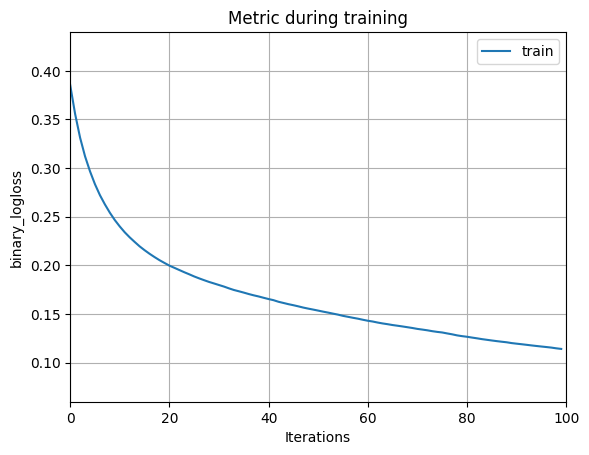

In [16]:
evals={}

model = lgb.train(params=params,
                  train_set=lgb_train,
                  valid_sets=[lgb_train],
                  valid_names=['train'],
                  callbacks=[lgb.record_evaluation(evals), 
                             lgb.log_evaluation(10)]
                  
                 )

lgb.plot_metric(evals)

# Your thoughts below...
print('='*100)
print("The logloss decreases over the 100 iterations by around 70%. We still don't know how the model performs in terms of the actual classification task though!")


# Training the model - II

`lightgbm` makes it easy to test on the unseen data at each iteration. Just add the `lgb_test` object to `valid_sets`.

Remember to set up an `evals={}` and include the `callback` argument, `lightgbm` will record and plot the logloss for all the specified sets.

How does the loss on the unseen data compare?

[10]	seen's binary_logloss: 0.246587	unseen's binary_logloss: 0.259638
[20]	seen's binary_logloss: 0.202542	unseen's binary_logloss: 0.227346
[30]	seen's binary_logloss: 0.181423	unseen's binary_logloss: 0.218897
[40]	seen's binary_logloss: 0.166695	unseen's binary_logloss: 0.21699
[50]	seen's binary_logloss: 0.154563	unseen's binary_logloss: 0.217353
[60]	seen's binary_logloss: 0.144127	unseen's binary_logloss: 0.218115
[70]	seen's binary_logloss: 0.135633	unseen's binary_logloss: 0.219572
[80]	seen's binary_logloss: 0.127265	unseen's binary_logloss: 0.221786
[90]	seen's binary_logloss: 0.12013	unseen's binary_logloss: 0.2228
[100]	seen's binary_logloss: 0.114128	unseen's binary_logloss: 0.224288
The logloss for the unseen set reaches a minimum after 20 interations and increases after that. This implies that we're probably overfitting!


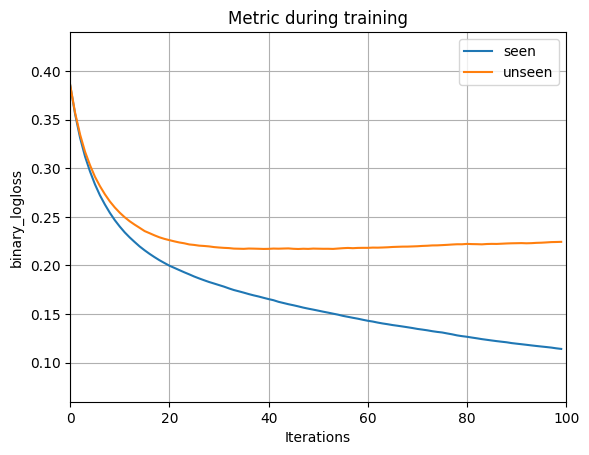

In [17]:
# Your code here...

evals={}

model = lgb.train(params=params,
                  train_set=lgb_train,
                  valid_sets=[lgb_train, lgb_test],
                  valid_names=['seen', 'unseen'],
                  callbacks=[lgb.record_evaluation(evals),
                             lgb.log_evaluation(10)]
                 )


lgb.plot_metric(evals)

# Your thoughts below...
print('='*100)
print("The logloss for the unseen set reaches a minimum after 20 interations and increases after that. This implies that we're probably overfitting!")


# Training the model - III

Above we only used a measure of logloss to evaluate the model. In classification tasks, we normally want to know  other metrics like auc and precision. 

Update `params` so that `metric` is a list that also includes `"auc"` and `"average_precision"`.

This time run the model for 200 iterations by changing the value of `num_boost_round` when calling `lgb.train()`. Remember to record the `evals` using the method from above but don't plot them just yet, we'll do that next!


In [18]:
# A dictionary to store the training results...
evals = {}

# Your code here...

params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc', 'average_precision'],
    'num_leaves': 31,
    'learning_rate': 0.1,
    'max_depth':-1,
    'verbose': 0,
    'seed': 0,
}

model = lgb.train(params=params,
                  train_set=lgb_train,
                  valid_sets=[lgb_train, lgb_test],
                  valid_names=['seen', 'unseen'],
                  num_boost_round=200,
                  callbacks=[lgb.record_evaluation(evals),
                             lgb.log_evaluation(10)]
                 )


[10]	seen's binary_logloss: 0.246587	seen's auc: 0.946859	seen's average_precision: 0.809738	unseen's binary_logloss: 0.259638	unseen's auc: 0.931172	unseen's average_precision: 0.754703
[20]	seen's binary_logloss: 0.202542	seen's auc: 0.957771	seen's average_precision: 0.835749	unseen's binary_logloss: 0.227346	unseen's auc: 0.938213	unseen's average_precision: 0.771252
[30]	seen's binary_logloss: 0.181423	seen's auc: 0.964437	seen's average_precision: 0.854427	unseen's binary_logloss: 0.218897	unseen's auc: 0.938085	unseen's average_precision: 0.77351
[40]	seen's binary_logloss: 0.166695	seen's auc: 0.970706	seen's average_precision: 0.875051	unseen's binary_logloss: 0.21699	unseen's auc: 0.937983	unseen's average_precision: 0.772685
[50]	seen's binary_logloss: 0.154563	seen's auc: 0.976104	seen's average_precision: 0.896845	unseen's binary_logloss: 0.217353	unseen's auc: 0.937075	unseen's average_precision: 0.772354
[60]	seen's binary_logloss: 0.144127	seen's auc: 0.98067	seen's ave

# Training the model - IV

Run the cell below to plot the data you stored in `metrics`. It loops through the individual metrics and plots them at each iteration.

What do you observe?

The model is overfitting quite quickly - 200 iterations is way too much. Peak unseen performance is likely around 25 iterations.


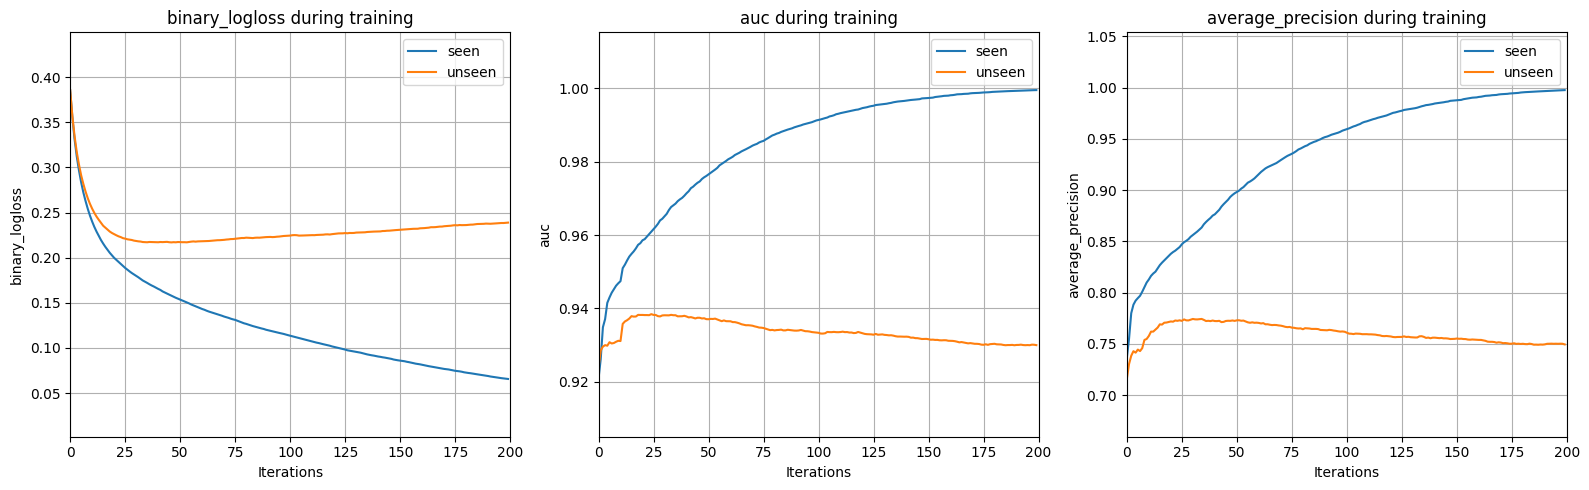

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

f, a = plt.subplots(1,3, figsize=(16,5))

for e, m in enumerate(['binary_logloss', 'auc', 'average_precision']):
    lgb.plot_metric(evals, metric=m, ax=a[e], title=f"{m} during training")
    
    
plt.tight_layout()
# Your thoughts below...

print("The model is overfitting quite quickly - 200 iterations is way too much. Peak unseen performance is likely around 25 iterations.")


# Investigating feature performance

`lightgbm` has built-in methods for seeing which features were most predictive.

There are two ways of measuring feature importance: 

* `split`: how many times a feature is used to make a decision in all the trees in the ensemble, except for leaf nodes. A feature which is used often to make decisions along the way is likely very informative.
* `gain`: the sum of the information gain score from using a feature in a tree.

These will each be normalised by the number of trees in the ensemble.

A trained `lightgbm` model has a very handy `.plot_importance()` method. Before running the cells below, what do you predict the most/least useful features will be when trying to predict whether a visitor to a website will make a purchase?

Unsurprisingly, features which relate to human activity (duration spent on pages etc.) are more informative than which operating system or browser is being used.
The feature related to how close the date is to a special day of the year was not very useful, which may be a surprise if you thought people would buy more around holidays etc.
This information could help you decide which kind of data to focus on gathering in the future.


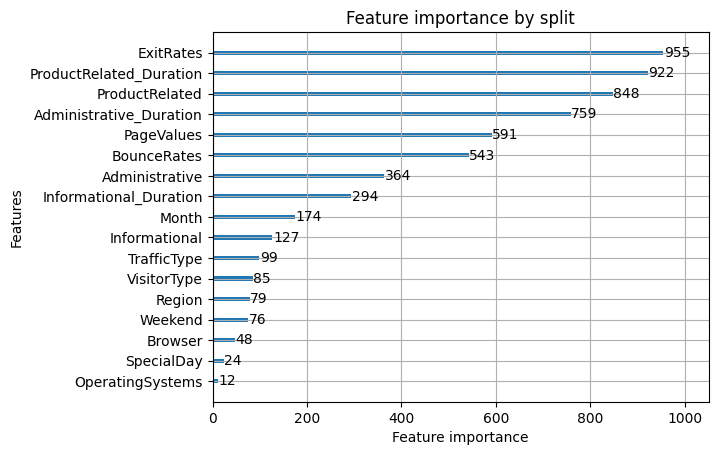

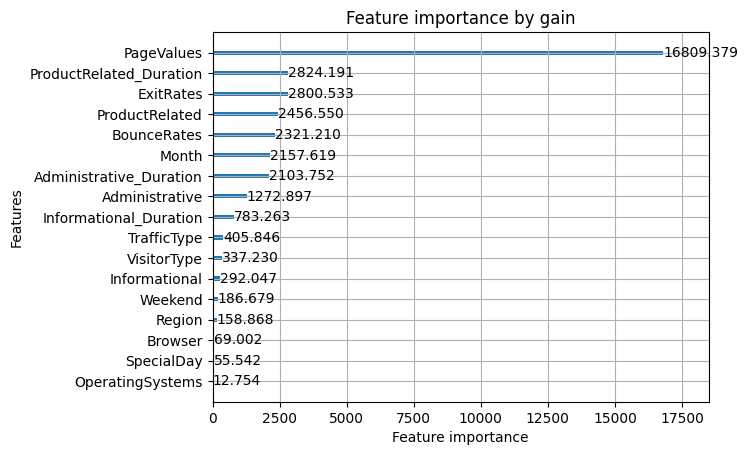

In [20]:
for imp_type in ['split', 'gain']:
    ax = lgb.plot_importance(model,
                             importance_type=imp_type,
                             dpi=100,
                             title=f"Feature importance by {imp_type}"
                             )
# Your thoughts below...

print("Unsurprisingly, features which relate to human activity (duration spent on pages etc.) are more informative than which operating system or browser is being used.")
print("The feature related to how close the date is to a special day of the year was not very useful, which may be a surprise if you thought people would buy more around holidays etc.")
print("This information could help you decide which kind of data to focus on gathering in the future.")


# Getting predictions for new data

So far we have used only the data available, but in practice it is likely that more data will come in and you will want to evaluate that.

In `lightgbm` you can save/load trained models and continue training them, if you have more labeled data.

If you want predictions for unlabelled data, you can do that too. You can pass a DataFrame of just the `X` values.

The model's `.predict()` method will return a score for each item. If it is >= 0.5 then it is in the positive class, otherwise the negative.

The two examples below would be classified as leading to a sale.

In [21]:
new_data_points = [
    [2.7, 99, 0.2, 30.0, 60, 12445.0, 0.0, 0.0, 20.5, 0.8, 'Feb', 1, 3, 2, 2, 'Returning_Visitor', True],
    [1.2, 99, 0.2, 1.0, 20, 942.0, 0.0, 0.0, 1.5, 0.28, 'Mar', 1, 1, 1, 1, 'Returning_Visitor', False],
]

new_data_points = pd.DataFrame(new_data_points, columns=data.columns[0:-1])

new_data_points[['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']] = new_data_points[['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']].astype('category')

model.predict(new_data_points)

array([0.8268223 , 0.73625813])

As `lightgbm` models output probabilities we can write a function to convert them into class labels. We'll use the default probability threshold of 0.5 (but this can be changed!). We need to convert to class labels if we want to make use of tools like `sklearn.metrics.classification_report`.

In [22]:
import numpy as np

def predict_class(model, data, threshold=0.5):
    
    y_pred = model.predict(data)
    
    return np.where(y_pred > threshold, 1, 0)

Let's check `predict_class()` on the new data points defined above.

In [23]:
predict_class(model, new_data_points)

array([1, 1])

Use `predict_class()` to calculate the `sklearn.metrics.accuracy_score` of our model on the test set.

In [24]:
from sklearn.metrics import accuracy_score

# Your code below...
accuracy_score(y_test, predict_class(model, X_test))


0.9000973078170613

If you also calculate the accuracy score for the training data you should get around 0.99, much higher than our test accuracy! We're clearly overfitting so let's do something about that.

# Finding the best model hyperparameters

As we saw, there are many hyperparameters to be tweaked - see [the documentation](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html) for more details.

One method is to try each combination manually, but this is time-consuming and poor practice.

Instead, `lightgbm` can be used with `sklearn`'s  cross-validation methods. It will train multiple models on subsets of the data (and evaluate on the unseen remainder) for each combination of parameters and find the best combination.

The model we trained had around 90% accuracy on our test data but was doing much better on our training data. `lightgbm` makes the following suggestions for reducing overfitting:

* Use small `max_bin` 
* Use small `num_leaves` 
* Increase `min_data_in_leaf`, this is the minimal number of data in one leaf
* Use `min_gain_to_split` to regularize the model growth

We can try a few of these and some others.

The `GridSearchCV` class from `sklearn` takes a model, with a dictionary of hyperparameter and values. Then you just fit/train it as usual, using the training dataset we created at the beginning, `X_train` and `y_train`.

We use `lgb.LGBMClassifier()` as our model here, we assign it to the variable `classifier`. Note that this is different to the syntax that we used above as weren't needing to communicate with `sklearn`.

Below, create a `GridSearchCV` in the same way you would an `sklearn` model: assign it to a variable named `gcv`, pass it the `classifier` as your basic model without parameters set, and also pass it `params`.

To speed things up, set `n_jobs=-1` to use all available CPU cores. Set `verbose=1` in the `GridSearchCV` so you get updates as it proceeds - useful for making sure it is actually working! Note that we've set `verbose=-1` in the model params so that it doesn't spit out 100s of warnings.

This is 24 models across 5 folds (so 120 models trained in total), which should take approximately 1 minute on EDUKATE. If it is going too slowly for you, try trimming a few of the items from each of the params. Alternatively you can include a wider range of items by uncommenting some of the values below, this will take longer but will result in a higher accuracy. Remember you can interrupt and restart the kernel if it is taking too long.

In [25]:
from sklearn.model_selection import GridSearchCV

params = dict(
    max_bin=[155, 255],#,355,455],
    num_leaves=[7, 15, 31],#30, 40, 50],
    min_data_in_leaf=[15, 20],#25],
    min_gain_to_split=[0, 0.01],#0.02, 0.03],
    verbose=[-1],
    seed=[0],        
)


classifier = lgb.LGBMClassifier()

# Your code below...

gcv = GridSearchCV(estimator=classifier, param_grid=params, n_jobs=-1, verbose=1)

gcv.fit(X_train, y_train)



Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_bin': [155, 255], 'min_data_in_leaf': [15, 20], 'min_gain_to_split': [0, 0.01], 'num_leaves': [7, 15, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

# What was the best model?

`GridSearchCV` evaluated each possible model using the accuracy metric.

The best model is stored inside `gcv` as `best_estimator_`. Its score is in `gcv.best_score_` and the actual hyperparameters used are in `gcv.best_params_`.

(The score here is not the score on the training set, but the average score across subsets of the training set.)

Take a look at these and then evaluate the best model on the test set `X_test` and `y_test` - the model in `gcv.best_estimator_` has a `.score()` method you can use. We don't need to use our `predict_class` function as we're using the `LGBMClassifier` which outputs classes in order to match the syntax of the `sklearn` library.

You should also check the performance of the `gcv.best_estimator_` on the training data, if there's still a gap then we're likely to be overfitting.

How does it compare to the model you trained before?

In [26]:
# Your code and thoughts below...

print(f"Best model accuracy: {gcv.best_score_}")

print(f"Best hyperparameters: {gcv.best_params_}")

best_model = gcv.best_estimator_

print(f"Accuracy on seen data: {best_model.score(X_train, y_train)}")

print(f"Accuracy on unseen data: {best_model.score(X_test, y_test)}")

# print("Accuracy has gone up to just over 90.7%.")
# print("The accuracy on both the seen and unseen data is far closer, this indicates that we've reduced the degree of overfitting that was takking place.")
# print("As the accuracy on the seen data is still higher we could probably continue to tune this model.")



Best model accuracy: 0.9028880475932937
Best hyperparameters: {'max_bin': 155, 'min_data_in_leaf': 15, 'min_gain_to_split': 0.01, 'num_leaves': 7, 'seed': 0, 'verbose': -1}
Accuracy on seen data: 0.9198659024548502
Accuracy on unseen data: 0.9078819331819656


# A closer look at the best model - I

The feature importances can be found in the `.feature_importances_` attribute of the model - check the `.best_model.importance_type` attribute to see if the model used `split` or `gain` for importances.

The feature names are stored in `.feature_name_`.

Create a DataFrame from the two lists (importances and names) and see which features are most important for this model.

Have they changed with these new hyperparameters?

In [27]:
best_model.importance_type

'split'

In [28]:
# Your code and thoughts below...

f_imp = pd.DataFrame(dict(feature=best_model.feature_name_, importance=best_model.feature_importances_))

f_imp = f_imp.sort_values('importance', ascending=False)

f_imp


,feature,importance
8,PageValues,86
7,ExitRates,73
5,ProductRelated_Duration,71
10,Month,67
4,ProductRelated,59
1,Administrative_Duration,55
6,BounceRates,44
14,TrafficType,34
0,Administrative,34
2,Informational,19


# A closer look at the best model - II

We used accuracy so far to evaluate performance, but it would be better to know the per-class performance.

Get the best model's predictions for `X_test` using its `.predict()` method.

Then, compare these to the true `y_test` classes using `sklearn.metrics.classification_report`.

Also take a look at the false positves/negatives using `sklearn.metrics.confusion_matrix`.

What do you observe?

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

# Your code and thoughts below...

best_model_pred = best_model.predict(X_test)

print(classification_report(y_test, best_model_pred))

print(confusion_matrix(y_test, best_model_pred))

print('='*53)

print("The classes are not very balanced - far more people do not buy than do buy something.")
print("Performance on the most common class is very strong, but we're interested in trying to model if someone buys something.")
print("If we wanted to try and address this we could use a more class-imbalance sensitive metric in our gridsearch.")
print("We have nearly half as many false negatives as true positives, our model is clearly not capturing something about our users purchase behaviour. ")



              precision    recall  f1-score   support

       False       0.93      0.96      0.95      2606
        True       0.73      0.64      0.68       477

    accuracy                           0.91      3083
   macro avg       0.83      0.80      0.81      3083
weighted avg       0.90      0.91      0.91      3083

[[2496  110]
 [ 174  303]]
The classes are not very balanced - far more people do not buy than do buy something.
Performance on the most common class is very strong, but we're interested in trying to model if someone buys something.
If we wanted to try and address this we could use a more class-imbalance sensitive metric in our gridsearch.
We have nearly half as many false negatives as true positives, our model is clearly not capturing something about our users purchase behaviour. 


# Conclusion and next steps

In this practical we went through the process of using `lightgbm` to classify customers, based on their behaviour on a website.

We trained and evaluated a single model before fine-tuning the hyperparameters to increase performance by a large margin.

We focused on classification but `lightgbm` also does regression. To take this practical further, you could try applying what you have learned to a regression dataset - see [the UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/datasets.php) for possible datasets.

Look into the `lgb.LGBMRegressor()` class, which is an `sklearn`-style class. Or use the `lgb.train()` method and change the `params` dictionary so that `objective` and `metric` are suitable for regression.

Another thing to bear in mind is that `lightgbm` is very fast - there's very little downside to just playing around with it!